In [26]:
import os
import numpy as np
import pandas as pd
from math import sqrt

from pylab import *
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns

from statistics import median
from scipy import signal
import scipy.stats as stats
from scipy.stats import sem,binom,lognorm,poisson,bernoulli,spearmanr

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [27]:
df=pd.read_csv('toy_dataset.csv')
df

,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No
...,...,...,...,...,...,...
149995,149996,Austin,Male,48,93669.0,No
149996,149997,Austin,Male,25,96748.0,No
149997,149998,Austin,Male,26,111885.0,No
149998,149999,Austin,Male,25,111878.0,No


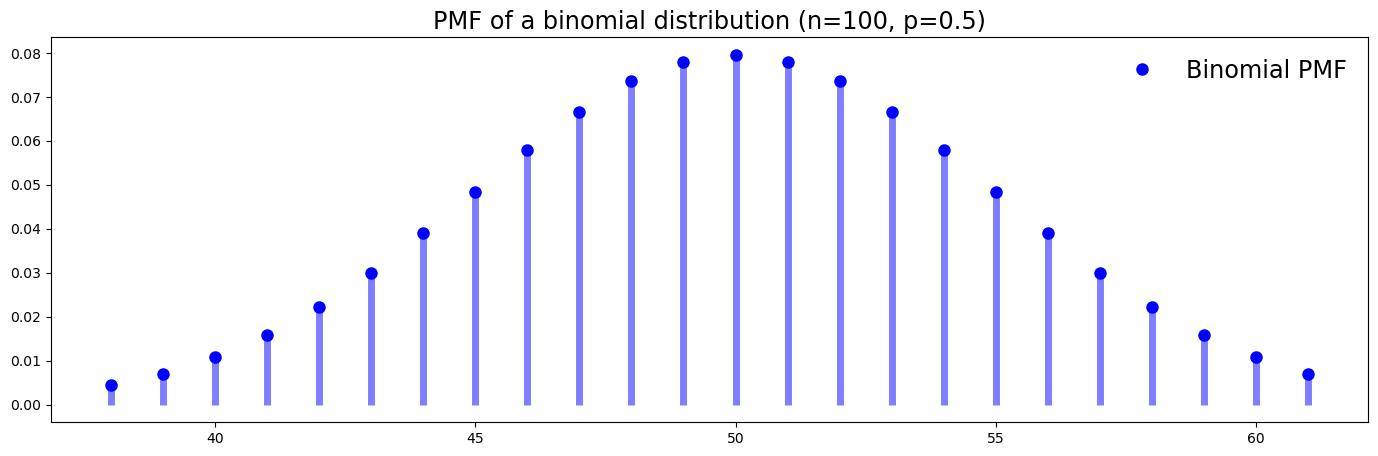

In [28]:
# PMF Visualization
n = 100
p = 0.5

fig, ax = plt.subplots(1, 1, figsize=(17,5))
x = np.arange(binom.ppf(0.01, n, p), binom.ppf(0.99, n, p))
ax.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='Binomial PMF')
ax.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)
rv = binom(n, p)
#ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1, label='frozen PMF')
ax.legend(loc='best', frameon=False, fontsize='xx-large')
plt.title('PMF of a binomial distribution (n=100, p=0.5)', fontsize='xx-large')
plt.show()

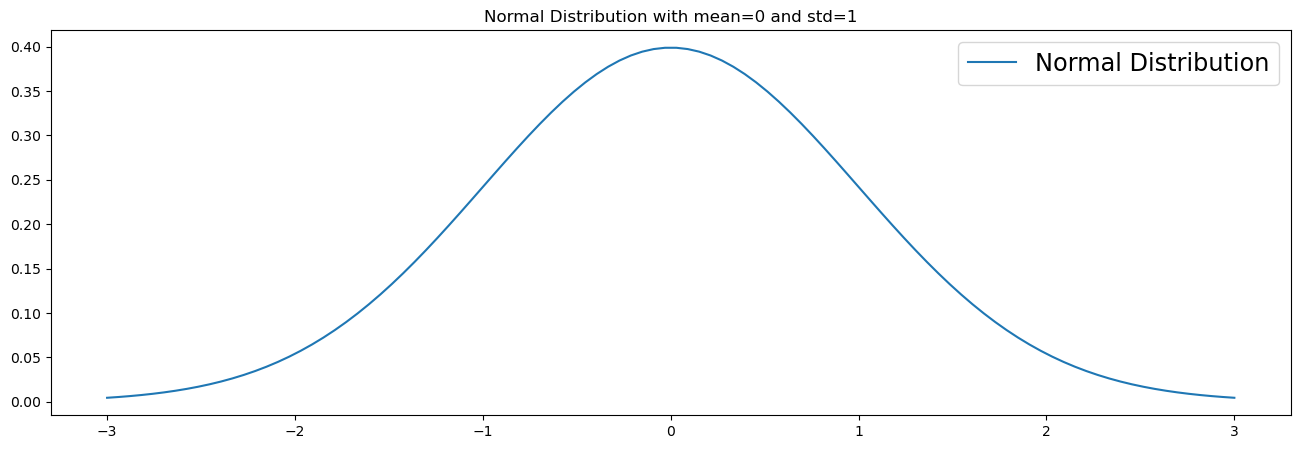

In [29]:
mu=0
variance=1
sigma=sqrt(variance)
x=np.linspace(mu -3*sigma, mu + 3*sigma,100)
plt.figure(figsize=(16,5))
plt.plot(x,stats.norm.pdf(x,mu,sigma),label='Normal Distribution')
plt.title('Normal Distribution with mean=0 and std=1')
plt.legend(fontsize='xx-large')
plt.show()

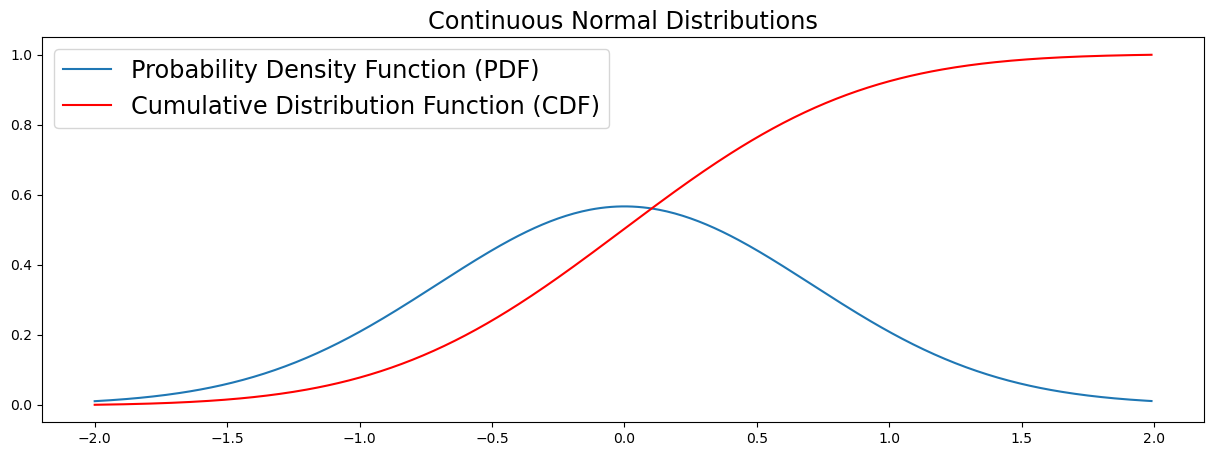

In [30]:
X=np.arange(-2,2,0.01)
Y=exp(-X ** 2)

Y= Y/(0.01 * Y).sum()
plt.figure(figsize=(15,5))
plt.title('Continuous Normal Distributions', fontsize='xx-large')
plot(X, Y, label='Probability Density Function (PDF)')
plot(X, np.cumsum(Y * 0.01), 'r', label='Cumulative Distribution Function (CDF)')
plt.legend(fontsize='xx-large')
plt.show()


In [31]:
uniform_dist = np.random.random(1000)
uniform_df = pd.DataFrame({'value' : uniform_dist})
uniform_dist = pd.Series(uniform_dist)

Text(0.5, 1.0, 'Scatterplot of a Random/Uniform Distribution')

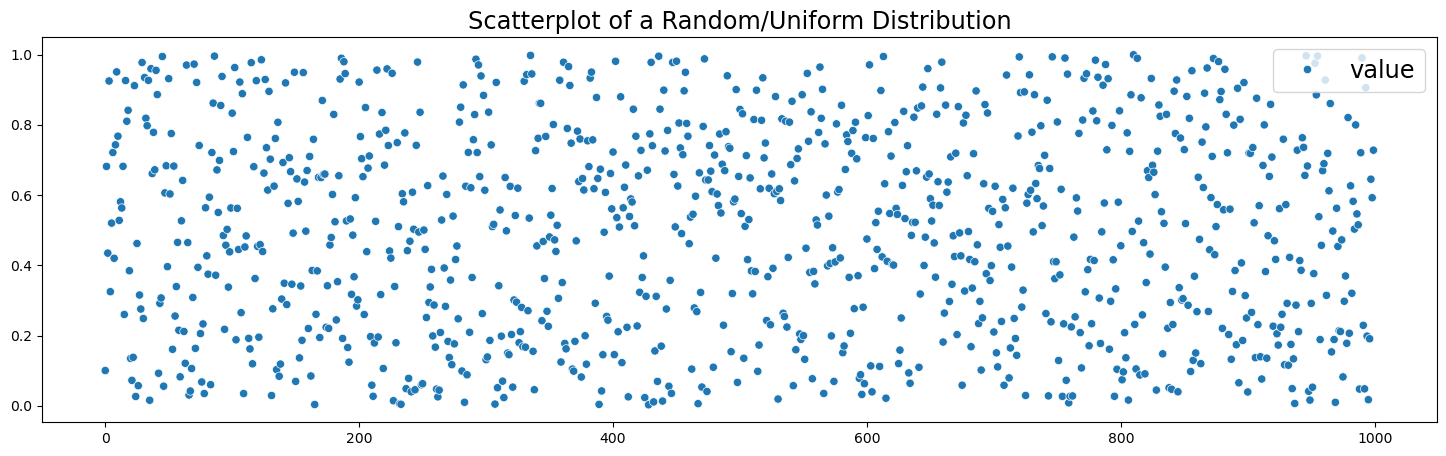

In [32]:
plt.figure(figsize=(18,5))
sns.scatterplot(data=uniform_df)
plt.legend(fontsize='xx-large')
plt.title('Scatterplot of a Random/Uniform Distribution', fontsize='xx-large')

C:\Users\Aisharani Patro\AppData\Local\Temp\ipykernel_21824\1098536719.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(uniform_df)


Text(0.5, 1.0, 'Random/Uniform distribution')

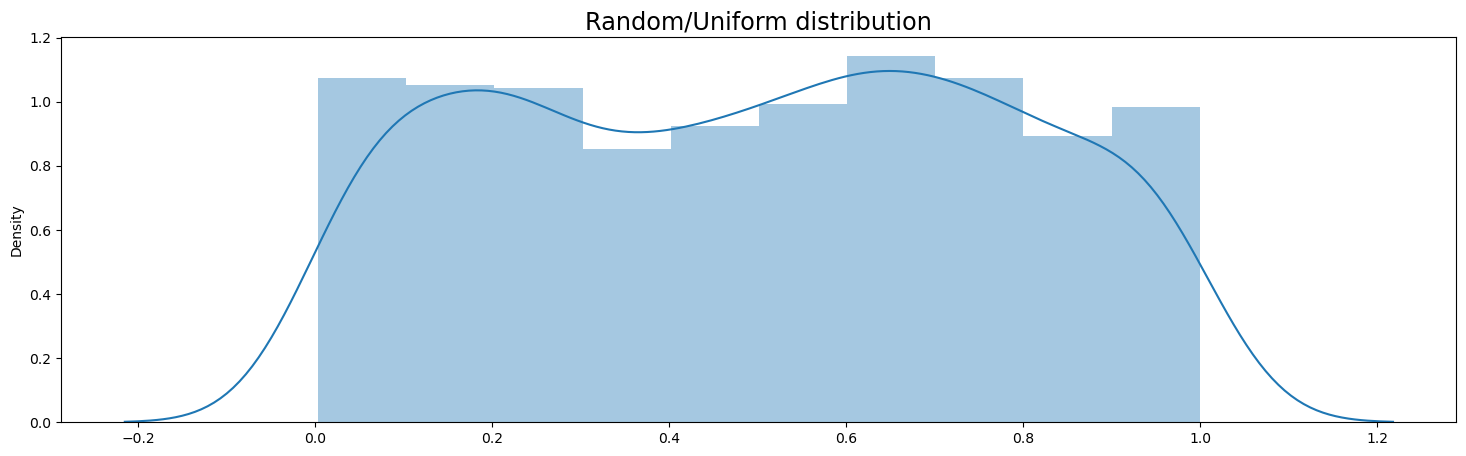

In [33]:
plt.figure(figsize=(18,5))
sns.distplot(uniform_df)
plt.title('Random/Uniform distribution', fontsize='xx-large')

In [34]:
normal_dist = np.random.randn(10000)
normal_df = pd.DataFrame({'value' : normal_dist})
# Create a Pandas Series for easy sample function
normal_dist = pd.Series(normal_dist)

normal_dist2 = np.random.randn(10000)
normal_df2 = pd.DataFrame({'value' : normal_dist2})
# Create a Pandas Series for easy sample function
normal_dist2 = pd.Series(normal_dist)

normal_df_total = pd.DataFrame({'value1' : normal_dist, 
                                'value2' : normal_dist2})

Text(0.5, 1.0, 'Scatterplot of a Normal Distribution')

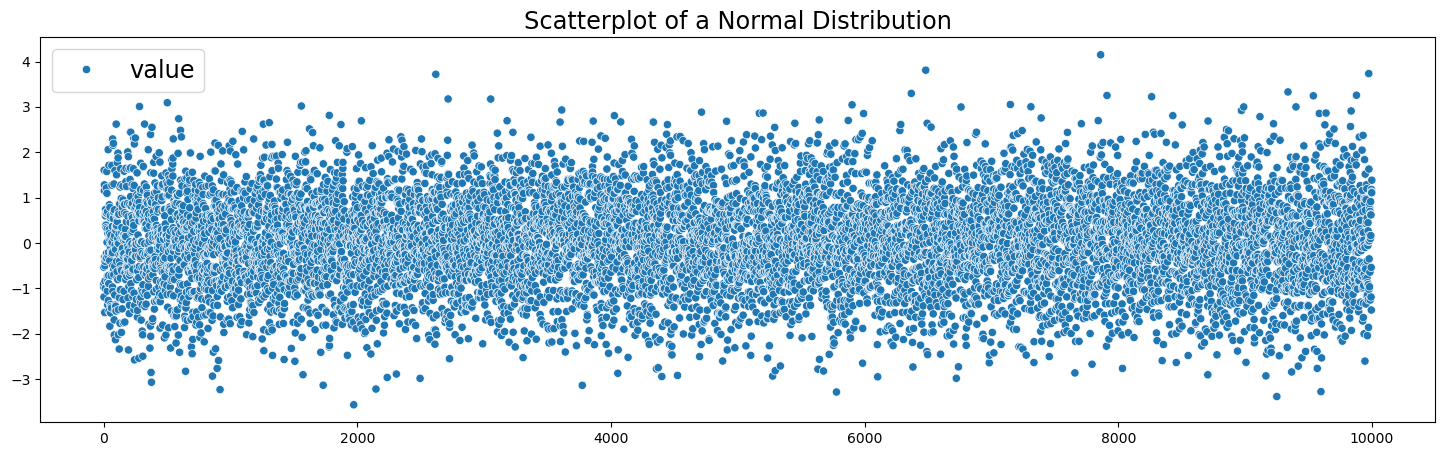

In [35]:
plt.figure(figsize=(18,5))
sns.scatterplot(data=normal_df)
plt.legend(fontsize='xx-large')
plt.title('Scatterplot of a Normal Distribution', fontsize='xx-large')

C:\Users\Aisharani Patro\AppData\Local\Temp\ipykernel_21824\3691376924.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_df)


Text(0.5, 1.0, 'Normal distribution (n=1000)')

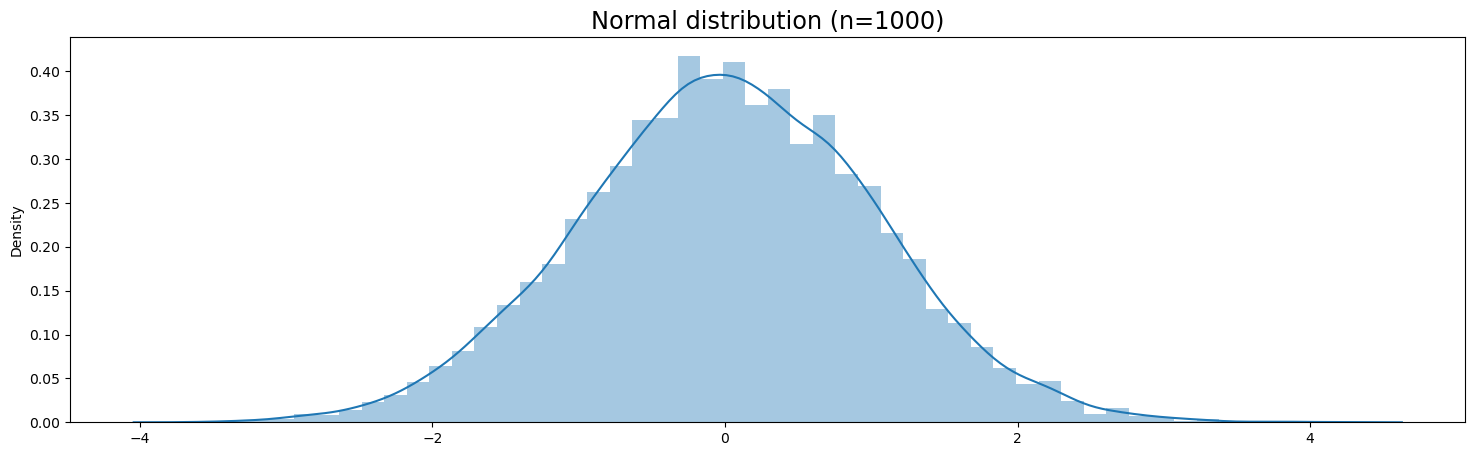

In [36]:
plt.figure(figsize=(18,5))
sns.distplot(normal_df)
plt.title('Normal distribution (n=1000)', fontsize='xx-large')

TypeError: annotate() missing 1 required positional argument: 'text'

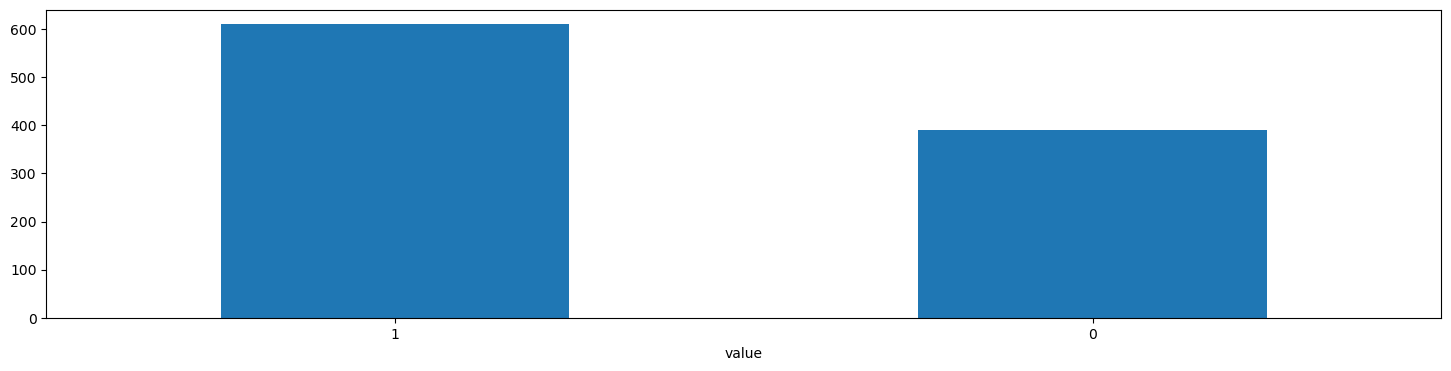

In [37]:

p = 0.6

# Create Bernoulli samples
bern_dist = bernoulli.rvs(p, size=1000)
bern_df = pd.DataFrame({'value' : bern_dist})
bern_values = bern_df['value'].value_counts()

# Plot Distribution
plt.figure(figsize=(18,4))
bern_values.plot(kind='bar', rot=0)
plt.annotate(xy=(0.85,300), 
             s='Samples that came up Tails\nn = {}'.format(bern_values[0]), 
             fontsize='large', 
             color='white')
plt.annotate(xy=(-0.2,300), 
             s='Samples that came up Heads\nn = {}'.format(bern_values[1]), 
             fontsize='large', 
             color='white')
plt.title('Bernoulli Distribution: p = 0.6, n = 1000')

In [ ]:
bern_dist = bernoulli.rvs(p, size=1000)

In [38]:
x = np.arange(0, 20, 0.1)
y = np.exp(-5)*np.power(5, x)/factorial(x)

plt.figure(figsize=(15,8))
plt.title('Poisson distribution with lambda=5', fontsize='xx-large')
plt.plot(x, y, 'bs')
plt.show()

NameError: name 'factorial' is not defined

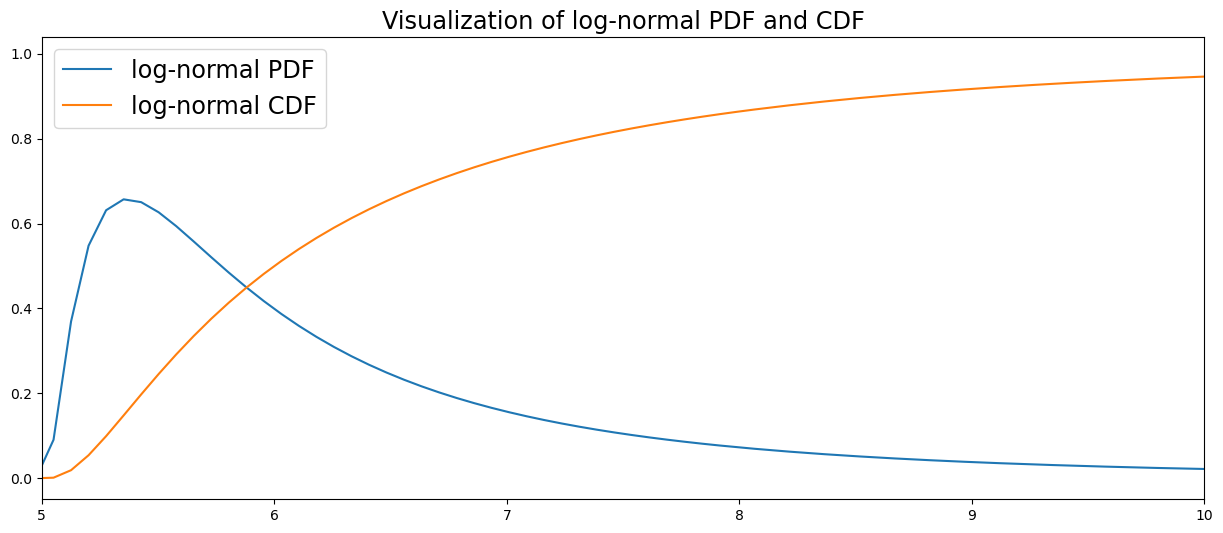

In [39]:
std = 1
mean = 5

# Create log-normal distribution
dist=lognorm(std,loc=mean)
x=np.linspace(0,15,200)

# Visualize log-normal distribution
plt.figure(figsize=(15,6))
plt.xlim(5, 10)
plt.plot(x,dist.pdf(x), label='log-normal PDF')
plt.plot(x,dist.cdf(x), label='log-normal CDF')
plt.legend(fontsize='xx-large')
plt.title('Visualization of log-normal PDF and CDF', fontsize='xx-large')
plt.show()

In [40]:
print('Summary Statistics for a normal distribution: ')
# Median
medi = median(normal_dist)
print('Median: ', medi)
display(normal_df.describe())

# Standard Deviation
std = sqrt(np.var(normal_dist))

print('The first four calculated moments of a normal distribution: ')
# Mean
mean = normal_dist.mean()
print('Mean: ', mean)

# Variance
var = np.var(normal_dist)
print('Variance: ', var)

# Return unbiased skew normalized by N-1
skew = normal_df['value'].skew()
print('Skewness: ', skew)

# Return unbiased kurtosis over requested axis using Fisher’s definition of kurtosis 
# (kurtosis of normal == 0.0) normalized by N-1
kurt = normal_df['value'].kurtosis()
print('Kurtosis: ', kurt)

Summary Statistics for a normal distribution: 
Median:  0.020311435913156897


,value
count,10000.000000
mean,0.017302
std,1.004991
min,-3.564485
25%,-0.651978
50%,0.020311
75%,0.704637
max,4.148782


The first four calculated moments of a normal distribution: 
Mean:  0.017302052691064603
Variance:  1.0099062897772635
Skewness:  -0.004122059150063724
Kurtosis:  0.01923057867065525


In [42]:
# Take sample
normal_df_sample = normal_df.sample(100)

# Calculate Expected Value (EV), population mean and bias
ev = normal_df_sample.mean()[0]
pop_mean = normal_df.mean()[0]
bias = ev - pop_mean

C:\Users\Aisharani Patro\AppData\Local\Temp\ipykernel_21824\2703849781.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ev = normal_df_sample.mean()[0]
C:\Users\Aisharani Patro\AppData\Local\Temp\ipykernel_21824\2703849781.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pop_mean = normal_df.mean()[0]


In [43]:
print('Sample mean (Expected Value): ', ev)
print('Population mean: ', pop_mean)
print('Bias: ', bias)

Sample mean (Expected Value):  0.23164736744316197
Population mean:  0.017302052691064603
Bias:  0.21434531475209737


In [44]:
from math import sqrt

Y = 100 # Actual Value
YH = 94 # Predicted Value

# MSE Formula 
def MSE(Y, YH):
     return np.square(YH - Y).mean()

# RMSE formula
def RMSE(Y, YH):
    return sqrt(np.square(YH - Y).mean())


print('MSE: ', MSE(Y, YH))

print('RMSE: ', RMSE(Y, YH))

MSE:  36.0
RMSE:  6.0


In [45]:
uni_sample = uniform_dist.sample(100)
norm_sample = normal_dist.sample(100)

print('Standard Error of uniform sample: ', sem(uni_sample))
print('Standard Error of normal sample: ', sem(norm_sample))

# The random samples from the normal distribution should have a higher standard error

Standard Error of uniform sample:  0.02606886541562347
Standard Error of normal sample:  0.10139211263590112


In [46]:
print('---Non-Representative samples:---\n')
# Convenience samples
con_samples = normal_dist[0:5]
print('Convenience samples:\n\n{}\n'.format(con_samples))

# Haphazard samples (Picking out some numbers)
hap_samples = [normal_dist[12], normal_dist[55], normal_dist[582], normal_dist[821], normal_dist[999]]
print('Haphazard samples:\n\n{}\n'.format(hap_samples))

# Purposive samples (Pick samples for a specific purpose)
# In this example we pick the 5 highest values in our distribution
purp_samples = normal_dist.nlargest(n=5)
print('Purposive samples:\n\n{}\n'.format(purp_samples))

print('---Representative samples:---\n')

# Simple (pseudo)random sample
rand_samples = normal_dist.sample(5)
print('Random samples:\n\n{}\n'.format(rand_samples))

# Systematic sample (Every 2000th value)
sys_samples = normal_dist[normal_dist.index % 2000 == 0]
print('Systematic samples:\n\n{}\n'.format(sys_samples))

# Stratified Sampling
# We will get 1 person from every city in the dataset
# We have 8 cities so that makes a total of 8 samples
df = pd.read_csv('toy_dataset.csv')

strat_samples = []

for city in df['City'].unique():
    samp = df[df['City'] == city].sample(1)
    strat_samples.append(samp['Income'].item())
    
print('Stratified samples:\n\n{}\n'.format(strat_samples))

# Cluster Sampling
# Make random clusters of ten people (Here with replacement)
c1 = normal_dist.sample(10)
c2 = normal_dist.sample(10)
c3 = normal_dist.sample(10)
c4 = normal_dist.sample(10)
c5 = normal_dist.sample(10)

# Take sample from every cluster (with replacement)
clusters = [c1,c2,c3,c4,c5]
cluster_samples = []
for c in clusters:
    clus_samp = c.sample(1)
    cluster_samples.extend(clus_samp)
print('Cluster samples:\n\n{}'.format(cluster_samples))    


---Non-Representative samples:---

Convenience samples:

0   -0.968833
1   -0.532072
2   -0.895622
3   -1.189144
4    1.605536
dtype: float64

Haphazard samples:

[np.float64(-0.40210109255593), np.float64(-1.5425164742980964), np.float64(-0.2990832786706862), np.float64(-0.0988319949666426), np.float64(2.0273007210601826)]

Purposive samples:

7861    4.148782
6482    3.808994
9975    3.734331
2619    3.718716
9338    3.329775
dtype: float64

---Representative samples:---

Random samples:

7222   -0.719475
3409    0.774522
6760    2.998157
5953   -0.935060
3854    1.681896
dtype: float64

Systematic samples:

0      -0.968833
2000    1.202372
4000   -0.645308
6000   -0.326708
8000    0.445542
dtype: float64

Stratified samples:

[28324.0, 106434.0, 84412.0, 115170.0, 98530.0, 75893.0, 98508.0, 90491.0]

Cluster samples:

[-0.04141928723807328, -0.9047764989151943, 0.08544235420702426, 1.2183024053840414, -0.9966747138931549]


In [47]:
# Covariance between Age and Income
print('Covariance between Age and Income: ')

df[['Age', 'Income']].cov()

Covariance between Age and Income: 


,Age,Income
Age,133.922426,-3.811863e+02
Income,-381.186341,6.244752e+08


In [48]:
# Correlation between two normal distributions
# Using Pearson's correlation
print('Pearson: ')
print(df[['Age', 'Income']].corr(method='pearson'))

# Negatively correlated data
x1 = [1, 3, 3, 4, 6, 7, 7, 9, 10, 10]
x2 = [9.7, 9.3, 7, 6, 7, 7.2, 6, 4.2, 4.5, 4]

# Positively correlated data
y1 = [0, 1, 2, 2.3, 3, 4, 4, 7, 9, 9.5]
y2 = [2.2, 4, 3, 5, 5.3, 5, 7, 9, 5, 10]

# Correlation with NumPy
print('\nx1,x2 correlation: \n', np.corrcoef(x1, x2))
print('\ny1,y2 correlation: \n', np.corrcoef(y1, y2))


Pearson: 
             Age    Income
Age     1.000000 -0.001318
Income -0.001318  1.000000

x1,x2 correlation: 
 [[ 1.         -0.88237093]
 [-0.88237093  1.        ]]

y1,y2 correlation: 
 [[1.        0.7737071]
 [0.7737071 1.       ]]


In [49]:
# Using Spearman's rho correlation
print('Spearman: ')
df[['Age', 'Income']].corr(method='spearman')

Spearman: 


,Age,Income
Age,1.000000,-0.001452
Income,-0.001452,1.000000


TypeError: regplot() takes from 0 to 1 positional arguments but 2 were given

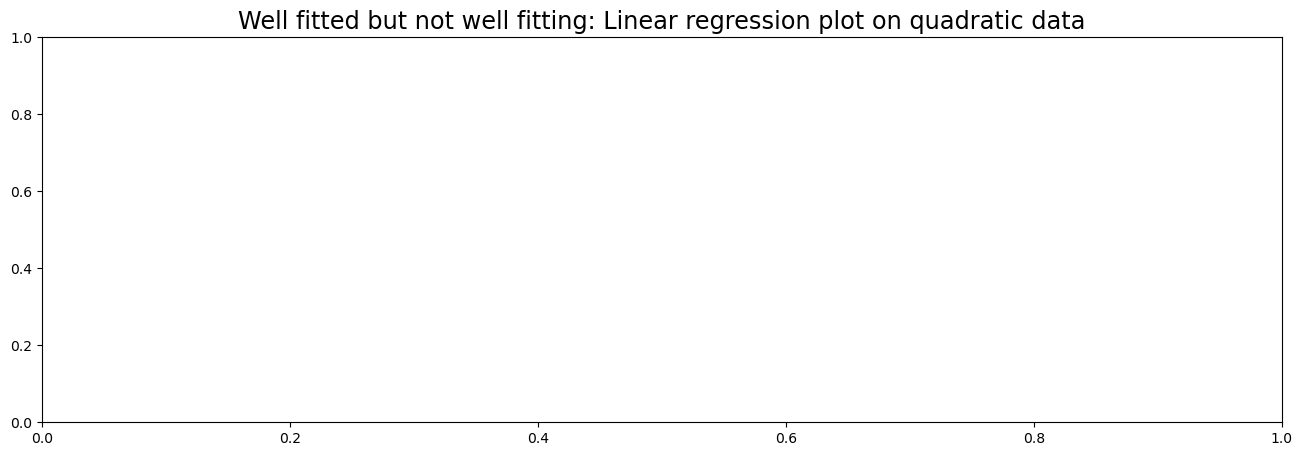

In [50]:
x = np.random.uniform(low=20, high=260, size=100)
y = 50000 + 2000*x - 4.5 * x**2 + np.random.normal(size=100, loc=0, scale=10000)

# Plot data with Linear Regression
plt.figure(figsize=(16,5))
plt.title('Well fitted but not well fitting: Linear regression plot on quadratic data', fontsize='xx-large')
sns.regplot(x, y)